In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '4'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openai
import dotenv
dotenv.load_dotenv()
openai.api_key = os.environ['OPENAI_API_KEY']
openai.api_base = os.environ.get("OPENAI_API_BASE", "https://api.openai.com/v1")
from data.serialize import SerializerSettings, serialize_arr
from models.utils import grid_iter
from models.promptcast import get_promptcast_predictions_data
from models.darts import get_arima_predictions_data
from models.llmtime import get_llmtime_predictions_data, get_scaler
from data.small_context import get_datasets
from models.validation_likelihood_tuning import get_autotuned_predictions_data
from loguru import logger

%load_ext autoreload
%autoreload 2

def plot_preds(train, test, pred_dict, model_name, show_samples=False):
    pred = pred_dict['median']
    pred = pd.Series(pred, index=test.index)
    plt.figure(figsize=(8, 6), dpi=100)
    plt.plot(train)
    plt.plot(test, label='Truth', color='black')
    plt.plot(pred, label=model_name, color='purple')
    # shade 90% confidence interval
    samples = pred_dict['samples']
    lower = np.quantile(samples, 0.05, axis=0)
    upper = np.quantile(samples, 0.95, axis=0)
    plt.fill_between(pred.index, lower, upper, alpha=0.3, color='purple')
    if show_samples:
        samples = pred_dict['samples']
        # convert df to numpy array
        samples = samples.values if isinstance(samples, pd.DataFrame) else samples
        for i in range(min(10, samples.shape[0])):
            plt.plot(pred.index, samples[i], color='purple', alpha=0.3, linewidth=1)
    plt.legend(loc='upper left')
    if 'NLL/D' in pred_dict:
        nll = pred_dict['NLL/D']
        if nll is not None:
            plt.text(0.03, 0.85, f'NLL/D: {nll:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
    plt.show()

/home/amir/miniconda3/envs/llmtime/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define models ##

In [2]:
# gpt4_hypers = dict(
#     alpha=0.3,
#     basic=True,
#     temp=1.0,
#     top_p=0.8,
#     settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=', ', bit_sep='', minus_sign='-')
# )

# gpt3_hypers = dict(
#     temp=0.7,
#     alpha=0.95,
#     beta=0.3,
#     basic=False,
#     settings=SerializerSettings(base=10, prec=3, signed=True, half_bin_correction=True)
# )


# promptcast_hypers = dict(
#     temp=0.7,
#     settings=SerializerSettings(base=10, prec=0, signed=True, 
#                                 time_sep=', ',
#                                 bit_sep='',
#                                 plus_sign='',
#                                 minus_sign='-',
#                                 half_bin_correction=False,
#                                 decimal_point='')
# )

# arima_hypers = dict(p=[12,30], d=[1,2], q=[0])

# model_hypers = {
#     # 'LLMTime GPT-3.5': {'model': 'gpt-3.5-turbo-instruct', **gpt3_hypers},
#     'LLMTime GPT-4': {'model': 'gpt-4', **gpt4_hypers},
#     # 'LLMTime GPT-3': {'model': 'text-davinci-003', **gpt3_hypers},
#     # 'PromptCast GPT-3': {'model': 'text-davinci-003', **promptcast_hypers},
#     # 'ARIMA': arima_hypers,
    
# }

# model_predict_fns = {
#     # 'LLMTime GPT-3': get_llmtime_predictions_data,
#     'LLMTime GPT-4': get_llmtime_predictions_data,
#     # 'PromptCast GPT-3': get_promptcast_predictions_data,
#     # 'ARIMA': get_arima_predictions_data,
# }

# model_names = list(model_predict_fns.keys())

In [3]:
# gptoss_hypers = dict(
#     alpha=0.3,
#     basic=True,
#     temp=1.0,
#     top_p=0.8,
#     settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=',', bit_sep='', minus_sign='-')
# )

# model_hypers = {
#    'gpt-oss': {'model': 'gpt-oss', **gptoss_hypers},
# }

# model_predict_fns = {
#     'gpt-oss': get_llmtime_predictions_data,
# }

# model_names = list(model_predict_fns.keys())

In [4]:
# gemma_hypers = dict(
#     alpha=0.3,
#     basic=True,
#     temp=1.0,
#     top_p=0.8,
#     settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=',', bit_sep='', minus_sign='-')
# )

# model_hypers = {
#    'gemma-12b': {'model': 'gemma-12b', **gemma_hypers},
# }

# model_predict_fns = {
#     'gemma-12b': get_llmtime_predictions_data,
# }

# model_names = list(model_predict_fns.keys())

In [5]:
qwen_hypers = dict(
    alpha=0.3,
    basic=True,
    temp=1.0,
    top_p=0.8,
    settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=',', bit_sep='', minus_sign='-')
)

model_hypers = {
   'qwen-30b': {'model': 'qwen-30b', **qwen_hypers},
}

model_predict_fns = {
    'qwen-30b': get_llmtime_predictions_data,
}

model_names = list(model_predict_fns.keys())

In [6]:
datasets = get_datasets()
ds_name = 'AirPassengersDataset'

data = datasets[ds_name]
train, test = data # or change to your own data

## Get results from Chronos ##

In [9]:
from models.chronos_forecast import get_predictions_chronos
import torch


quantiles, median = get_predictions_chronos(
    input_tensor=torch.tensor(train.values),
    prediction_length=29,
    quantiles=[0.1, 0.5, 0.9]
)

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


In [10]:
Co_variate_1 = pd.concat([train, test])/2 - 15
Co_variate_2 = pd.Series(1.0, index=Co_variate_1.index)
Co_variate_1.iloc[120:131] = 0.0
Co_variate_2.iloc[120:131] = 0.0
Co_variates = [Co_variate_1.values, Co_variate_2.values]
Co_variate_texts = ["This variable is a co-variate that is related to the target variable. It contains information on both past and future.", "This variable is usually a constant, but when it drops in value to zero, the target variable also drops significantly to zero. It contains information on both past and future"]
Co_variates

[array([ 41. ,  44. ,  51. ,  49.5,  45.5,  52.5,  59. ,  59. ,  53. ,
         44.5,  37. ,  44. ,  42.5,  48. ,  55.5,  52.5,  47.5,  59.5,
         70. ,  70. ,  64. ,  51.5,  42. ,  55. ,  57.5,  60. ,  74. ,
         66.5,  71. ,  74. ,  84.5,  84.5,  77. ,  66. ,  58. ,  68. ,
         70.5,  75. ,  81.5,  75.5,  76.5,  94. , 100. , 106. ,  89.5,
         80.5,  71. ,  82. ,  83. ,  83. , 103. , 102.5,  99.5, 106.5,
        117. , 121. , 103.5,  90.5,  75. ,  85.5,  87. ,  79. , 102.5,
         98.5, 102. , 117. , 136. , 131.5, 114.5,  99.5,  86.5,  99.5,
        106. , 101.5, 118.5, 119.5, 120. , 142.5, 167. , 158.5, 141. ,
        122. , 103.5, 124. , 127. , 123.5, 143.5, 141.5, 144. , 172. ,
        191.5, 187.5, 162.5, 138. , 120.5, 138. , 142.5, 135.5, 163. ,
        159. , 162.5, 196. , 217.5, 218.5, 187. , 158.5, 137.5, 153. ,
        155. , 144. , 166. , 159. , 166.5, 202.5, 230.5, 237.5, 187. ,
        164.5, 140. , 153.5,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
      

In [ ]:
plt.plot(Co_variate_2, label='Co-variate')
# plt.plot(test, label='Future (what is going to be predicted)')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Co-variate for {ds_name}')

In [11]:
# map back to test positions
affected_in_test = range(120 - len(train), 131 - len(train))

# set them to zero in test
test.iloc[affected_in_test] = 0.0
test

Month
1958-08-01    505.0
1958-09-01    404.0
1958-10-01    359.0
1958-11-01    310.0
1958-12-01    337.0
1959-01-01      0.0
1959-02-01      0.0
1959-03-01      0.0
1959-04-01      0.0
1959-05-01      0.0
1959-06-01      0.0
1959-07-01      0.0
1959-08-01      0.0
1959-09-01      0.0
1959-10-01      0.0
1959-11-01      0.0
1959-12-01    405.0
1960-01-01    417.0
1960-02-01    391.0
1960-03-01    419.0
1960-04-01    461.0
1960-05-01    472.0
1960-06-01    535.0
1960-07-01    622.0
1960-08-01    606.0
1960-09-01    508.0
1960-10-01    461.0
1960-11-01    390.0
1960-12-01    432.0
Freq: MS, Name: #Passengers, dtype: float64

In [12]:
median.cpu().numpy().squeeze().shape

(29,)

In [13]:
Co_variates

[array([ 41. ,  44. ,  51. ,  49.5,  45.5,  52.5,  59. ,  59. ,  53. ,
         44.5,  37. ,  44. ,  42.5,  48. ,  55.5,  52.5,  47.5,  59.5,
         70. ,  70. ,  64. ,  51.5,  42. ,  55. ,  57.5,  60. ,  74. ,
         66.5,  71. ,  74. ,  84.5,  84.5,  77. ,  66. ,  58. ,  68. ,
         70.5,  75. ,  81.5,  75.5,  76.5,  94. , 100. , 106. ,  89.5,
         80.5,  71. ,  82. ,  83. ,  83. , 103. , 102.5,  99.5, 106.5,
        117. , 121. , 103.5,  90.5,  75. ,  85.5,  87. ,  79. , 102.5,
         98.5, 102. , 117. , 136. , 131.5, 114.5,  99.5,  86.5,  99.5,
        106. , 101.5, 118.5, 119.5, 120. , 142.5, 167. , 158.5, 141. ,
        122. , 103.5, 124. , 127. , 123.5, 143.5, 141.5, 144. , 172. ,
        191.5, 187.5, 162.5, 138. , 120.5, 138. , 142.5, 135.5, 163. ,
        159. , 162.5, 196. , 217.5, 218.5, 187. , 158.5, 137.5, 153. ,
        155. , 144. , 166. , 159. , 166.5, 202.5, 230.5, 237.5, 187. ,
        164.5, 140. , 153.5,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
      

## Running LLMTime and Visualizing Results ##

In [12]:
chatgpt_sys_message = '''
You are a helpful assistant that performs time series predictions. The user will provide a sequence and you will predict the remaining sequence. The sequence is represented by decimal strings separated by commas.
'''

extra_input = '''
Note: Please continue the following sequence without producing any additional text. Do not say anything like 'the next terms in the sequence are', JUST return the numbers. The target sequence:
'''

2025-09-18 14:28:09.181 | DEBUG    | models.llmtime:get_llmtime_predictions_data:226 - Transformed medians: [array([[2.67527952, 2.41240976, 2.01013933, 1.92251607, 2.03801946,
        2.10174543, 2.17741996, 2.30885493, 2.35266647, 2.40444406,
        2.64341654, 2.89035472, 2.87442331, 2.65934794, 2.26902607,
        2.14555715, 2.20928312, 2.27300909, 2.34868379, 2.42834117,
        2.44427275, 2.48410144, 2.78679989, 3.04170412, 3.00187526,
        2.77086848, 2.38851248, 2.2969062 , 2.39647818]])]
2025-09-18 14:28:09.183 | DEBUG    | models.llmtime:get_llmtime_predictions_data:227 - Transformed medians shape: [(1, 29)]
2025-09-18 14:28:09.184 | DEBUG    | models.llmtime:get_llmtime_predictions_data:234 - Medians that are added to the extra input: 2675,2412,2010,1922,2038,2101,2177,2308,2352,2404,2643,2890,2874,2659,2269,2145,2209,2273,2348,2428,2444,2484,2786,3041,3001,2770,2388,2296,2396,
2025-09-18 14:28:09.187 | DEBUG    | models.llmtime:get_llmtime_predictions_data:253 - Co-va

Sampling with best hyper... defaultdict(<class 'dict'>, {'model': 'qwen-30b', 'alpha': 0.3, 'basic': True, 'temp': 1.0, 'top_p': 0.8, 'settings': SerializerSettings(base=10, prec=3, signed=True, fixed_length=False, max_val=10000000.0, time_sep=',', bit_sep='', plus_sign='', minus_sign='-', half_bin_correction=True, decimal_point='', missing_str=' Nan'), 'dataset_name': 'AirPassengersDataset'}) 
 with NLL inf


  0%|          | 0/1 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 16/16 [00:30<00:00,  1.93s/it]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-09-18 14:28:55.911 | DEBUG    | models.qwen:qwen_completion_fn:162 - Batch size: 5
2025-09-18 14:28:55.912 | DEBUG    | models.qwen:qwen_completion_fn:163 - Num samples: 10
2025-09-18 14:28:55.913 | DEBUG    | models.qwen:qwen_completion_fn:164 - num_samples // batchsize: 2
2025-09-18 14:28:55.919 | DEBUG    | models.qwen:qwen_completion_fn:167 - input_str: 
You are a helpful assistant that performs time series predictions. The user will provide a sequence and you will predict the remaining sequence. The sequence is represented by decimal strings separated by commas.
Co-variates: The follo

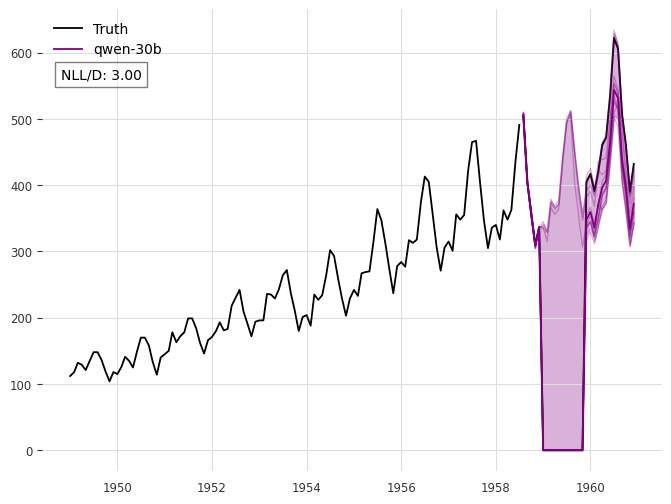

In [13]:
out = {}
for model in model_names: # GPT-4 takes a about a minute to run
    
    # serializer_setting = model_hypers[model].get('settings', None)
    # scaler = get_scaler(
    #     median.cpu().numpy().squeeze(), 
    #     alpha=model_hypers['LLMTime GPT-4'].get('alpha', 0.95),
    #     beta=model_hypers['LLMTime GPT-4'].get('beta', 0.3),
    #     basic=model_hypers['LLMTime GPT-4'].get('basic', False)
    # )
    # transformed_input_arrs = np.array([scaler.transform(median.cpu().numpy().squeeze())])

    # serialized_median = serialize_arr(transformed_input_arrs.squeeze(), settings=serializer_setting)
    
    # logger.debug(f"serialized_median: {serialized_median}")

    model_hypers[model].update({'dataset_name': ds_name}) # for promptcast
    hypers = list(grid_iter(model_hypers[model]))
    num_samples = 10

    pred_dict = get_autotuned_predictions_data(
        train,
        test,
        hypers,
        num_samples,
        model_predict_fns[model],
        verbose=False,
        parallel=False,
        chatgpt_sys_message=chatgpt_sys_message,
        extra_input=extra_input,
        few_shot_median=[median.cpu().numpy().squeeze()],
        Co_variates=Co_variates,
        Co_variate_texts=Co_variate_texts,
    )

    out[model] = pred_dict
    plot_preds(train, test, pred_dict, model, show_samples=True)

In [14]:
train

Month
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
              ...  
1958-03-01    362.0
1958-04-01    348.0
1958-05-01    363.0
1958-06-01    435.0
1958-07-01    491.0
Freq: MS, Name: #Passengers, Length: 115, dtype: float64

In [15]:
pred_dict['samples']

Month,1958-08-01,1958-09-01,1958-10-01,1958-11-01,1958-12-01,1959-01-01,1959-02-01,1959-03-01,1959-04-01,1959-05-01,...,1960-03-01,1960-04-01,1960-05-01,1960-06-01,1960-07-01,1960-08-01,1960-09-01,1960-10-01,1960-11-01,1960-12-01
0,504.4260,403.9868,355.6404,309.7916,336.5516,0.0892,0.0892,0.0892,0.0892,0.0892,...,347.0772,384.5412,394.3532,450.5492,528.1532,513.8812,426.4652,384.5412,321.2092,358.6732
1,505.8532,403.9868,357.4244,309.4348,335.3028,0.0892,0.0892,0.0892,0.0892,0.0892,...,421.6484,464.2860,474.9900,541.3548,633.7660,613.7852,507.8156,458.9340,382.7572,425.7516
2,505.8532,403.9868,353.6780,305.5100,336.3732,0.0892,0.0892,0.0892,0.0892,0.0892,...,351.1804,387.0388,397.3860,455.3660,535.1108,520.3036,430.3900,388.4660,324.9556,362.7764
3,509.7780,405.5924,358.6732,309.0780,334.7676,0.0892,0.0892,0.0892,0.0892,0.0892,...,414.3340,458.5772,469.2812,532.9700,624.1324,606.6492,499.9660,455.7228,387.2172,429.3196
4,506.7452,403.9868,357.7812,308.0076,336.3732,0.0892,0.0892,0.0892,0.0892,0.0892,...,334.5892,366.8796,377.9404,430.2116,503.1772,488.1916,403.6300,361.8844,307.2940,343.5092
5,501.9284,403.9868,354.7484,310.5052,336.7300,0.0892,0.0892,0.0892,0.0892,0.0892,...,367.2364,405.4140,416.4748,474.2764,552.9508,538.3220,448.0516,405.7708,342.0820,381.1516
6,509.5996,403.9868,358.6732,310.5052,336.3732,334.7676,328.7020,373.4804,364.3820,370.2692,...,421.8268,415.9396,422.3620,493.0084,554.1996,541.3548,476.5956,411.1228,356.8892,398.2780
7,509.2428,403.9868,354.3916,304.6180,336.3732,0.0892,0.0892,0.0892,0.0892,0.0892,...,347.4340,385.0764,395.0668,451.2628,528.6884,514.4164,427.0004,385.0764,321.7444,359.2084
8,506.0316,403.8084,352.7860,308.1860,335.3028,344.9364,330.6644,378.8324,368.4852,377.2268,...,436.0988,438.9532,440.7372,502.2852,565.0820,543.6740,489.4404,426.4652,372.5884,422.3620
9,504.4260,403.9868,354.7484,304.9748,337.0868,337.0868,314.9652,366.1660,355.9972,363.4900,...,372.9452,362.9548,371.6964,446.0892,508.1724,524.5852,409.1604,360.4572,310.1484,342.6172


In [16]:
hello = [41000, 44000, 51000, 49500, 45500, 52500, 59000, 59000, 53000, 44500, 37000, 44000, 42500, 48000, 55500, 52500, 47500, 59500, 70000, 70000, 64000, 51500, 42000, 55000, 57500, 60000, 74000, 66500, 71000, 74000, 84500, 84500, 77000, 66000, 58000, 68000, 70500, 75000, 81500, 75500, 76500, 94000, 100000, 106000, 89500, 80500, 71000, 82000, 83000, 83000, 103000, 102500, 99500, 106500, 117000, 121000, 103500, 90500, 75000, 85500, 87000, 79000, 102500, 98500, 102000, 117000, 136000, 131500, 114500, 99500, 86500, 99500, 106000, 101500, 118500, 119500, 120000, 142500, 167000, 158500, 141000, 122000, 103500, 124000, 127000, 123500, 143500, 141500, 144000, 172000, 191500, 187500, 162500, 138000, 120500, 138000, 142500, 135500, 163000, 159000, 162500, 196000, 217500, 218500, 187000, 158500, 137500, 153000, 155000, 144000, 166000, 159000, 166500, 202500, 230500, 237500, 187000, 164500, 140000, 153500, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 187500, 193500, 180500, 194500, 215500, 221000, 252500, 296000, 288000, 239000, 215500, 180000, 201000, ]
hello[120:132]


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 187500]